In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv("diabetes.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [4]:
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [5]:
df=df.drop(['ID','No_Pation'],axis=1) #we donot need this column for future analysis

In [6]:
df['Gender'].unique() #results shows F,M and f . So f is converted into F at next step

array(['F', 'M', 'f'], dtype=object)

In [7]:
df['Gender']=df['Gender'].replace('f', 'F')

In [8]:
df['CLASS'].unique() #got two Ys and two Ns as must be only one of them

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [9]:
df['CLASS']=df['CLASS'].replace({'Y ':'Y','N ':'N'})

In [10]:
df['CLASS'].unique() #good to go

array(['N', 'P', 'Y'], dtype=object)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  1000 non-null   object 
 1   AGE     1000 non-null   int64  
 2   Urea    1000 non-null   float64
 3   Cr      1000 non-null   int64  
 4   HbA1c   1000 non-null   float64
 5   Chol    1000 non-null   float64
 6   TG      1000 non-null   float64
 7   HDL     1000 non-null   float64
 8   LDL     1000 non-null   float64
 9   VLDL    1000 non-null   float64
 10  BMI     1000 non-null   float64
 11  CLASS   1000 non-null   object 
dtypes: float64(8), int64(2), object(2)
memory usage: 93.9+ KB


In [12]:
#replacing N and Y in CLASS column to 0 and 1
df['CLASS']=df['CLASS'].replace({'N':-1,'P':0,'Y':1})

In [13]:
#replacing age gender into 0 and 1
df['Gender']=df['Gender'].replace({'F':0,'M':1})

# Analysis

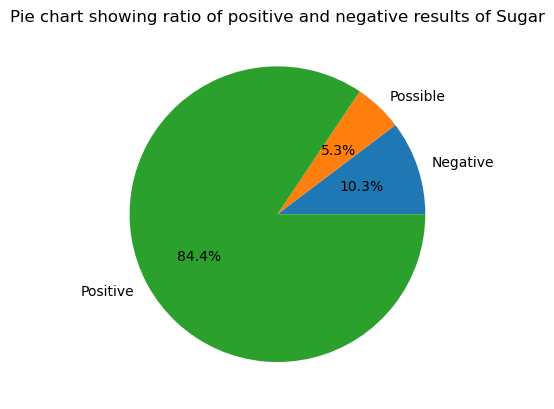

In [15]:
negative=(df['CLASS']==-1).sum()
possible =(df['CLASS']==0).sum()
positive=(df['CLASS']==1).sum()
results=[negative,possible,positive]
labels=['Negative','Possible' ,'Positive']

plt.pie(results, labels=labels,autopct='%1.1f%%')
plt.title("Pie chart showing ratio of positive and negative results of Sugar")
plt.show()

In [16]:
# Standardize BMI and HbA1c
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['BMI_scaled', 'HbA1c_scaled','Chol_scaled']] = scaler.fit_transform(df[['BMI', 'HbA1c','Chol']])


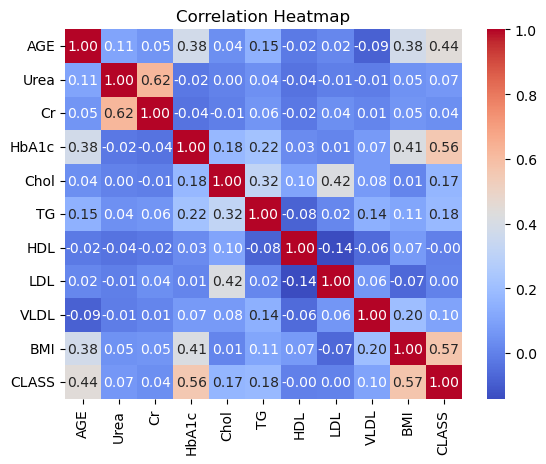

In [17]:
correlation_matrix=df[['AGE','Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI','CLASS']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

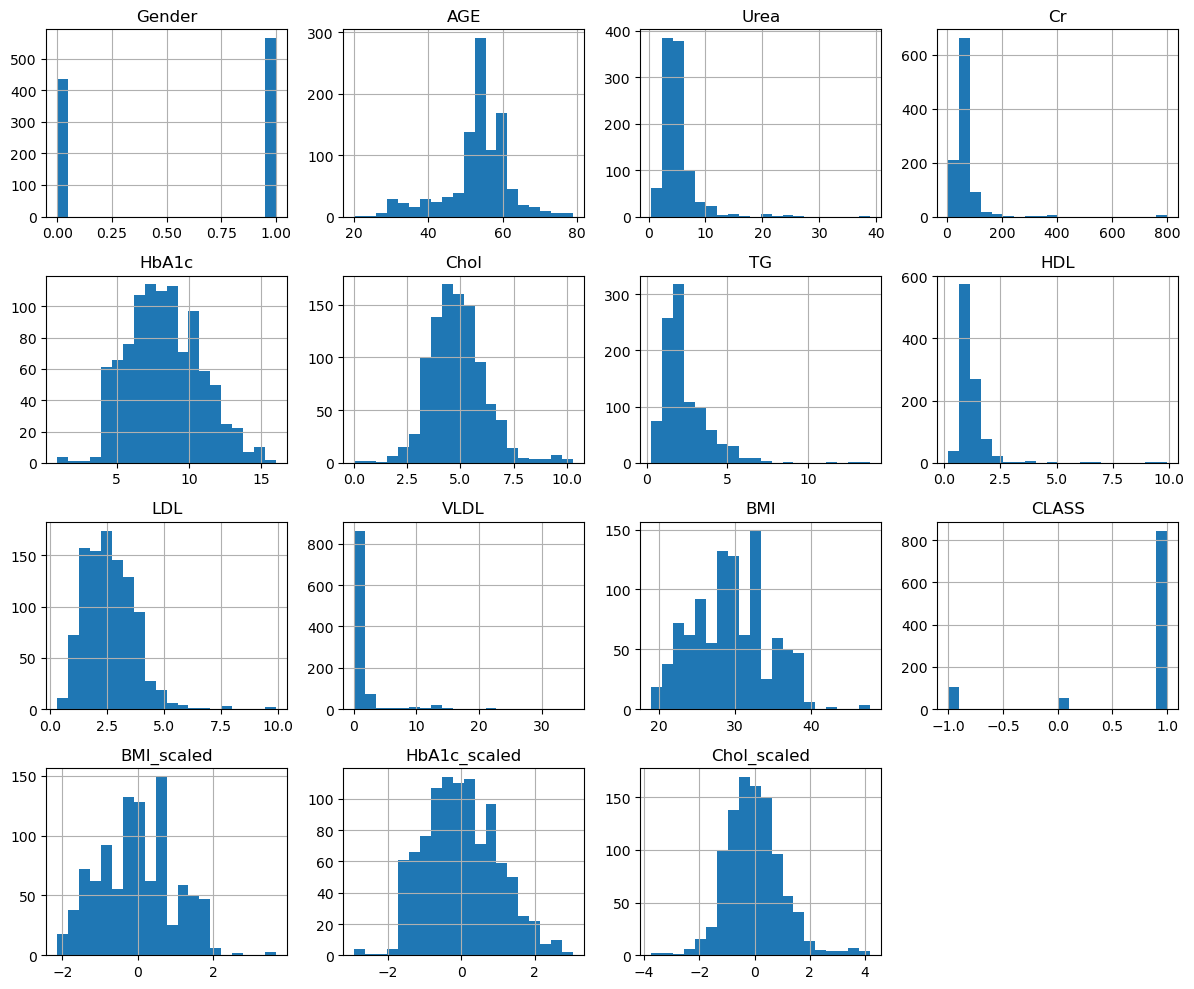

In [18]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

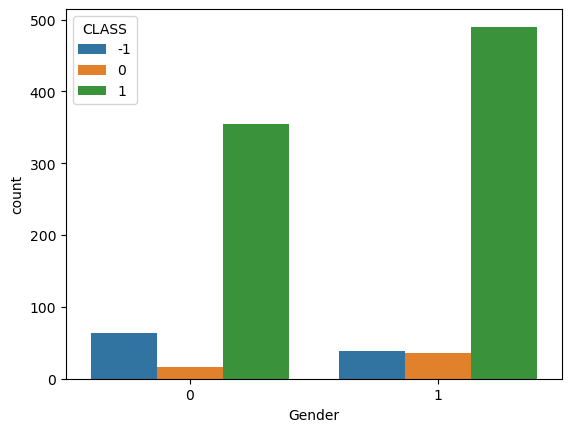

In [19]:



sns.countplot(x='Gender',data=df, hue='CLASS')
plt.show()

/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sagarbasnet/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in 

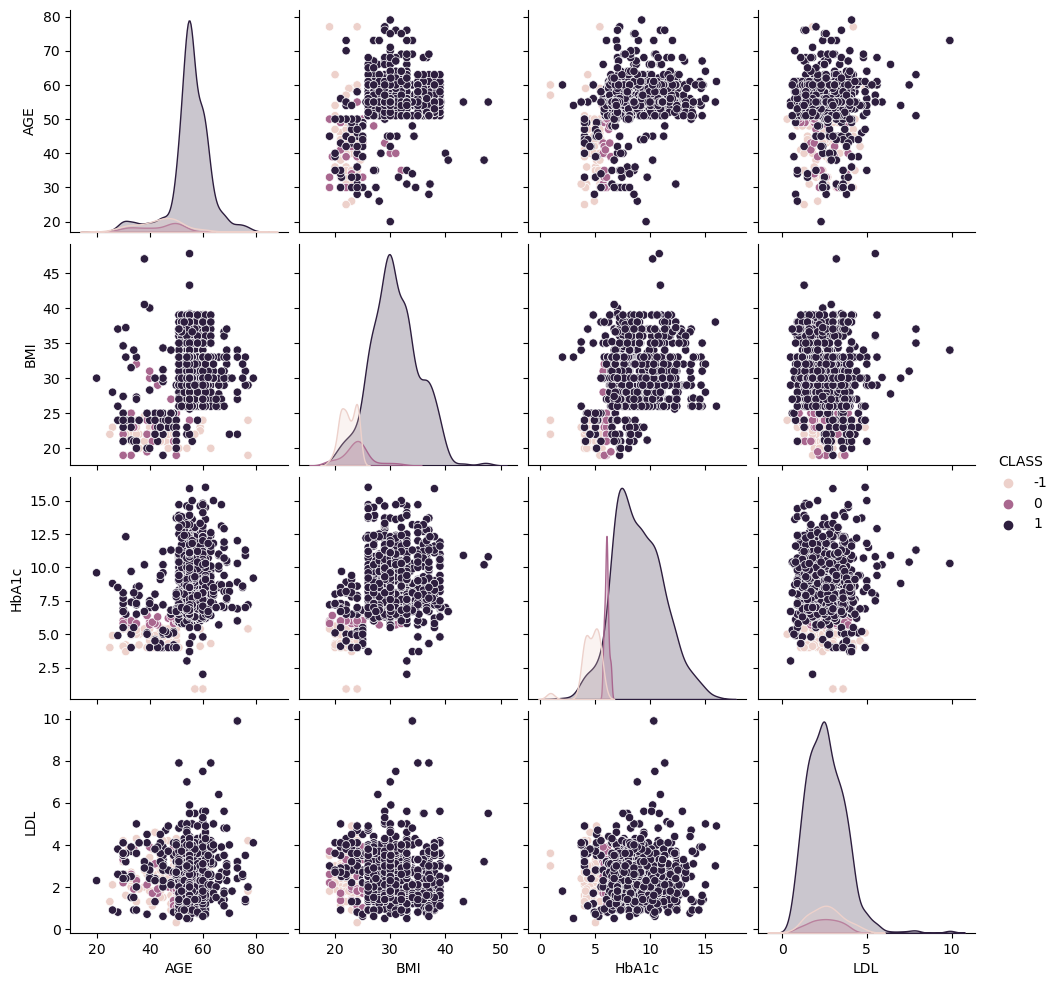

In [20]:


sns.pairplot(df, hue='CLASS', diag_kind='kde', vars=['AGE', 'BMI', 'HbA1c', 'LDL'])
plt.show()


Data Preprocessing

In [23]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
le_gender=LabelEncoder()
le_class=LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
df['CLASS'] = le_class.fit_transform(df['CLASS'])

In [24]:
# seperating dataset into features X and target y
X=df.drop('CLASS',axis=1)
y=df['CLASS']

In [25]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [26]:
#splitting training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify =y)

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

In [28]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)

[Text(0.5, 0.9285714285714286, 'x[11] <= -0.973\ngini = 0.275\nsamples = 800\nvalue = [82, 43, 675]'),
 Text(0.2631578947368421, 0.7857142857142857, 'x[12] <= -1.039\ngini = 0.599\nsamples = 153\nvalue = [82, 27, 44]'),
 Text(0.15789473684210525, 0.6428571428571429, 'x[5] <= 0.067\ngini = 0.325\nsamples = 103\nvalue = [82, 0, 21]'),
 Text(0.10526315789473684, 0.5, 'gini = 0.0\nsamples = 70\nvalue = [70, 0, 0]'),
 Text(0.21052631578947367, 0.5, 'x[6] <= -0.321\ngini = 0.463\nsamples = 33\nvalue = [12, 0, 21]'),
 Text(0.15789473684210525, 0.35714285714285715, 'x[7] <= 0.523\ngini = 0.415\nsamples = 17\nvalue = [12, 0, 5]'),
 Text(0.10526315789473684, 0.21428571428571427, 'x[2] <= 0.571\ngini = 0.245\nsamples = 14\nvalue = [12, 0, 2]'),
 Text(0.05263157894736842, 0.07142857142857142, 'gini = 0.0\nsamples = 12\nvalue = [12, 0, 0]'),
 Text(0.15789473684210525, 0.07142857142857142, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.21052631578947367, 0.21428571428571427, 'gini = 0.0\nsam

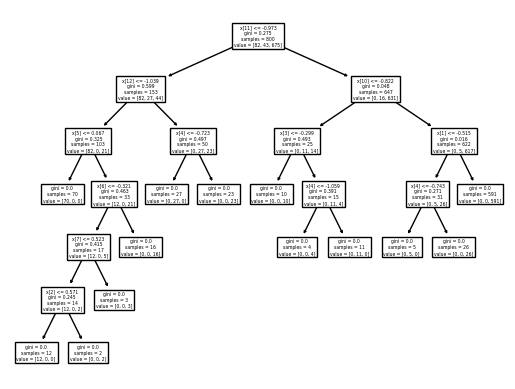

In [29]:
tree.plot_tree(clf)

In [30]:
prediction=clf.predict (X_test)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy=accuracy_score(y_test,prediction)

In [33]:
accuracy

0.99

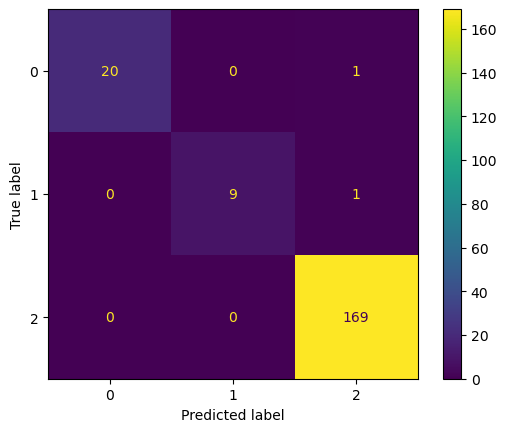

In [34]:
cm= confusion_matrix(y_test,prediction,labels=clf.classes_)
display= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
display.plot()
plt.show()

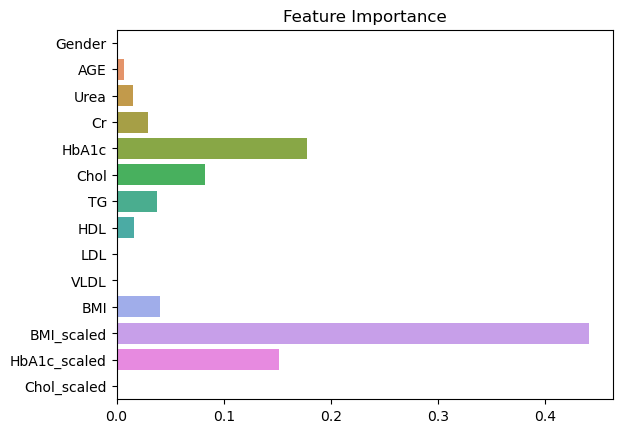

In [35]:
#ploting feature importance
importances= clf.feature_importances_
features=X.columns
sns.barplot(x=importances,y=features)
plt.title('Feature Importance')
plt.show()

In [36]:
#checking if there is any overfitting
train_accuracy=clf.score(X_train,y_train)
test_accuracy=clf.score(X_test,y_test)
print("Training Accuracy :", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy: 0.99


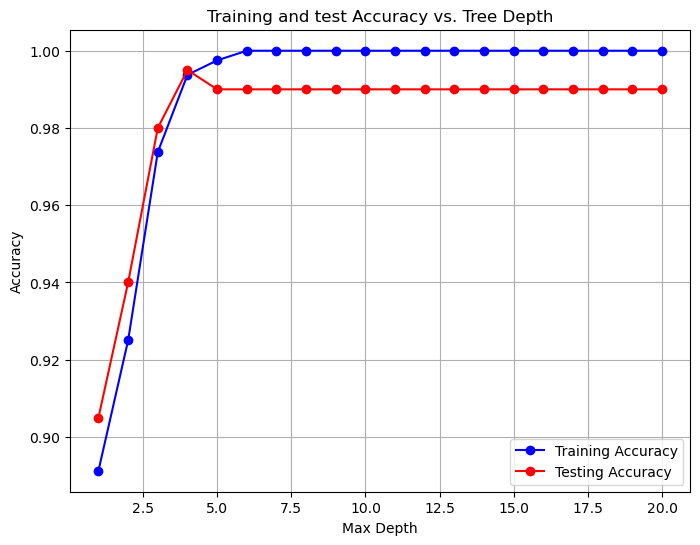

In [38]:
from sklearn.tree import DecisionTreeClassifier
# Step 2: Train Decision Tree and Store Scores
train_scores = []
val_scores = []
max_depth_range = range(1, 21)  # Varying max_depth from 1 to 20

for depth in max_depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict on training and validation sets
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_scores.append(train_accuracy)
    val_scores.append(val_accuracy)

# Step 3: Plot Training and Validation Scores
plt.figure(figsize=(8, 6))
plt.plot(max_depth_range, train_scores, label='Training Accuracy', color='blue', marker='o')
plt.plot(max_depth_range, val_scores, label='Testing Accuracy', color='red', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training and test Accuracy vs. Tree Depth')
plt.legend(loc='best')
plt.grid()
plt.show()

In [40]:
#cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X_scaled, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))


Cross-Validation Scores: [0.82  0.99  0.99  0.985 0.965]
Mean CV Score: 0.95


In [65]:
# seperating dataset into features X and target y
X_final=df.drop(['CLASS', 'Gender','LDL','VLDL','Chol_scaled','BMI','HbA1c_scaled'],axis=1)
y_final=df['CLASS']

In [67]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X_final)

In [69]:
X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify =y)

In [83]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train) #final model

In [73]:
prediction=clf.predict (X_test)

In [75]:
accuracy=accuracy_score(y_test,prediction)

In [77]:
print(accuracy)

0.99


In [79]:
# saving the trained model 
import pickle
with open('diabetes_model.pkl', 'wb') as file:
    pickle.dump(clf,file)

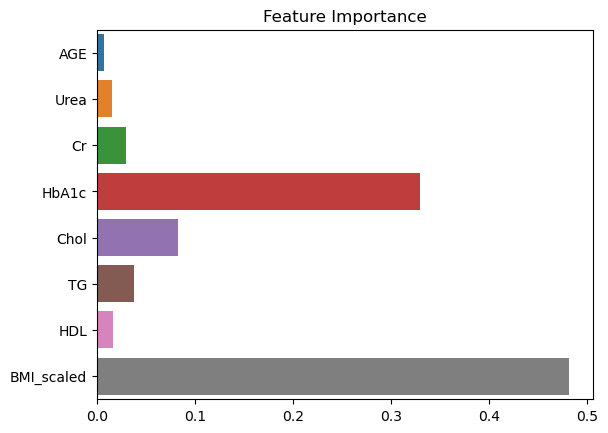

In [85]:
#ploting feature importance just to be sure 
importances= clf.feature_importances_
features=X_final.columns
sns.barplot(x=importances,y=features)
plt.title('Feature Importance')
plt.show()